<a href="https://colab.research.google.com/github/danah1-a/AAASE/blob/main/AI_Agents_Report_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

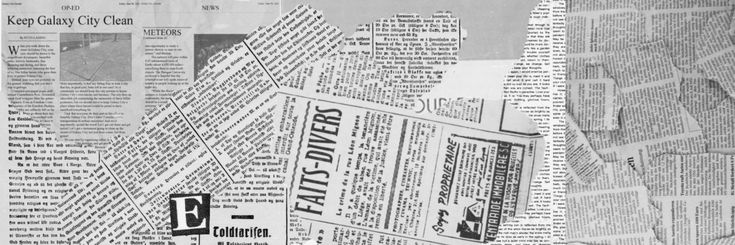
# **AI Agents for Report Generation**
**By Danah Alhamdi**

This notebook demonstrates a simple **multi-agent report generation system**

The system uses five specialized agents:

1. **Research Agent** - organizes the user-provided information
2. **Summarization Agent** - extracts the most important points
3. **Writing Agent** - generates a structured draft report
4. **Review Agent** - improves formatting and consistency
5. **Report Manager Agent** - coordinates the workflow and saves the final report

## **Workflow**

```text
START
  ↓
Research Agent
  ↓
Summarization Agent
  ↓
Writing Agent
  ↓
Review Agent
  ↓
Report Manager Agent
  ↓
END
```



## **1. Import Required Libraries**



In [1]:
from datetime import datetime
from pathlib import Path
from typing import TypedDict
import re
import textwrap

print("All libraries were imported successfully.")

All libraries were imported successfully.


## **2. Define the Shared State**

The shared state stores the topic, input notes, outputs of all agents, execution logs and the saved report path.

In [2]:
class ReportState(TypedDict):
    topic: str
    input_notes: str
    research_notes: str
    summarized_notes: str
    draft_report: str
    final_report: str
    manager_summary: str
    logs: list[str]
    output_file: str

## **3. Helper Functions**



In [3]:
def add_log(logs: list[str], message: str) -> list[str]:
    timestamp = datetime.now().strftime("%H:%M:%S")
    entry = f"[{timestamp}] {message}"
    print(entry)
    return [*logs, entry]


def clean_text(text: str) -> str:
    text = re.sub(r"\\s+", " ", text.strip())
    return text


def split_sentences(text: str) -> list[str]:
    text = clean_text(text)
    if not text:
        return []

    sentences = re.split(r"(?<=[.!?])\\s+", text)
    return [sentence.strip() for sentence in sentences if sentence.strip()]


def safe_filename(text: str) -> str:
    filename = re.sub(r"[^A-Za-z0-9]+", "_", text.strip().lower())
    filename = re.sub(r"_+", "_", filename).strip("_")
    return filename[:60] or "generated_report"


def title_case_heading(text: str) -> str:
    return " ".join(word.capitalize() for word in text.split())

## **4. Research Agent**

The Research Agent receives the topic and the user-provided notes. It organizes them into clear research categories.

Because this notebook does not use an API, the research source is the information entered by the user.

In [4]:
def research_agent(state: ReportState) -> dict:
    logs = add_log(state.get("logs", []), "Research Agent started.")

    topic = clean_text(state["topic"])
    notes = clean_text(state["input_notes"])
    sentences = split_sentences(notes)

    if not topic:
        raise ValueError("The topic cannot be empty.")

    if not sentences:
        raise ValueError("Please provide notes or information for the report.")

    definitions = []
    benefits = []
    challenges = []
    examples = []
    recommendations = []
    general_findings = []

    benefit_words = [
        "benefit", "advantage", "improve", "increase", "support",
        "help", "opportunity", "effective", "efficient"
    ]

    challenge_words = [
        "challenge", "risk", "problem", "limitation", "cost",
        "privacy", "security", "bias", "difficult"
    ]

    example_words = [
        "example", "for instance", "such as", "case", "application"
    ]

    recommendation_words = [
        "should", "recommend", "must", "need to", "important to"
    ]

    definition_words = [
        "is defined", "refers to", "means", "is a", "is an"
    ]

    for sentence in sentences:
        lower_sentence = sentence.lower()

        if any(word in lower_sentence for word in recommendation_words):
            recommendations.append(sentence)
        elif any(word in lower_sentence for word in challenge_words):
            challenges.append(sentence)
        elif any(word in lower_sentence for word in benefit_words):
            benefits.append(sentence)
        elif any(word in lower_sentence for word in example_words):
            examples.append(sentence)
        elif any(word in lower_sentence for word in definition_words):
            definitions.append(sentence)
        else:
            general_findings.append(sentence)

    def bullet_section(title: str, items: list[str]) -> str:
        if not items:
            return f"### {title}\n- No specific information was provided."
        bullets = "\n".join(f"- {item}" for item in items)
        return f"### {title}\n{bullets}"

    research_notes = f"""
# Detailed Research Notes

## Topic
{topic}

{bullet_section("Definitions and Background", definitions)}

{bullet_section("Main Findings", general_findings)}

{bullet_section("Benefits and Opportunities", benefits)}

{bullet_section("Challenges and Risks", challenges)}

{bullet_section("Examples and Applications", examples)}

{bullet_section("Recommendations", recommendations)}
""".strip()

    logs = add_log(
        logs,
        f"Research Agent completed after organizing {len(sentences)} statements."
    )

    return {
        "research_notes": research_notes,
        "logs": logs,
    }

## **5. Summarization Agent**

This agent extracts the strongest points from the organized research notes and produces a concise summary.

In [5]:
def summarization_agent(state: ReportState) -> dict:
    logs = add_log(
        state.get("logs", []),
        "Summarization Agent started."
    )

    lines = state["research_notes"].splitlines()

    bullet_points = [
        line[2:].strip()
        for line in lines
        if line.strip().startswith("- ")
        and "No specific information was provided" not in line
    ]

    unique_points = []
    seen = set()

    for point in bullet_points:
        normalized = point.lower()

        if normalized not in seen:
            seen.add(normalized)
            unique_points.append(point)

    selected_points = unique_points[:10]

    if not selected_points:
        selected_points = [
            "The available information was limited and requires further input."
        ]

    summary_bullets = "\n".join(
        f"- {point}" for point in selected_points
    )

    summarized_notes = f"""
# Summarized Notes

## Topic
{state["topic"]}

## Key Points
{summary_bullets}

## Summary Statement
The topic was analyzed using the information provided by the user. The key points above represent the most relevant findings for the final report.
""".strip()

    logs = add_log(
        logs,
        "Summarization Agent completed."
    )

    return {
        "summarized_notes": summarized_notes,
        "logs": logs,
    }

## **6. Writing Agent**

The Writing Agent converts the summarized notes into a complete professional report.

In [6]:
def extract_bullets(markdown_text: str) -> list[str]:
    return [
        line[2:].strip()
        for line in markdown_text.splitlines()
        if line.strip().startswith("- ")
    ]


def writing_agent(state: ReportState) -> dict:
    logs = add_log(
        state.get("logs", []),
        "Writing Agent started."
    )

    points = extract_bullets(state["summarized_notes"])

    main_findings = points[:4]
    benefits = [
        point for point in points
        if any(
            word in point.lower()
            for word in [
                "benefit", "advantage", "improve",
                "support", "help", "opportunity"
            ]
        )
    ]

    challenges = [
        point for point in points
        if any(
            word in point.lower()
            for word in [
                "challenge", "risk", "problem",
                "privacy", "security", "bias", "limitation"
            ]
        )
    ]

    recommendations = [
        point for point in points
        if any(
            word in point.lower()
            for word in [
                "should", "must", "recommend",
                "need to", "important to"
            ]
        )
    ]

    if not benefits:
        benefits = [
            "The topic may provide useful opportunities when applied appropriately."
        ]

    if not challenges:
        challenges = [
            "Successful implementation requires careful planning and continuous evaluation."
        ]

    if not recommendations:
        recommendations = [
            "Organizations should evaluate their needs before implementation.",
            "Stakeholders should monitor performance and address emerging risks."
        ]

    def paragraph(items: list[str]) -> str:
        return " ".join(items)

    def bullets(items: list[str]) -> str:
        return "\n".join(f"- {item}" for item in items)

    report_title = title_case_heading(state["topic"])

    draft_report = f"""
# {report_title}

## Executive Summary

This report examines {state["topic"]}. It is based on the information supplied by the user and organized through a sequence of specialized report-generation agents. The report presents the main findings, potential benefits, challenges, and practical recommendations related to the topic.

## Introduction

{state["topic"]} is an important subject that can influence individuals, organizations, and society. Understanding its main characteristics, opportunities, and limitations supports better planning and decision-making.

## Main Findings

{paragraph(main_findings)}

## Benefits and Opportunities

{bullets(benefits)}

## Challenges and Risks

{bullets(challenges)}

## Recommendations

{bullets(recommendations)}

## Conclusion

The analysis shows that {state["topic"]} includes both opportunities and challenges. Its success depends on informed planning, responsible implementation, and continuous review. The information provided in this report can serve as a starting point for further research and discussion.

## Source Note

This report was generated from the notes entered by the user. No external API or online source was used.
""".strip()

    logs = add_log(
        logs,
        "Writing Agent completed."
    )

    return {
        "draft_report": draft_report,
        "logs": logs,
    }

## **7. Review Agent**

The Review Agent improves formatting, removes duplicated lines, and checks that all required report sections are present.

In [7]:
def review_agent(state: ReportState) -> dict:
    logs = add_log(
        state.get("logs", []),
        "Review Agent started."
    )

    report = state["draft_report"].strip()

    report = re.sub(r"\n{3,}", "\n\n", report)

    lines = report.splitlines()
    reviewed_lines = []
    previous_line = None

    for line in lines:
        cleaned_line = line.rstrip()

        if cleaned_line and cleaned_line == previous_line:
            continue

        reviewed_lines.append(cleaned_line)
        previous_line = cleaned_line

    final_report = "\n".join(reviewed_lines).strip()

    required_sections = [
        "## Executive Summary",
        "## Introduction",
        "## Main Findings",
        "## Benefits and Opportunities",
        "## Challenges and Risks",
        "## Recommendations",
        "## Conclusion",
    ]

    missing_sections = [
        section
        for section in required_sections
        if section not in final_report
    ]

    if missing_sections:
        final_report += (
            "\n\n## Review Note\n"
            "The following expected sections were missing: "
            + ", ".join(missing_sections)
        )

    final_report += (
        "\n\n---\n"
        f"Report reviewed automatically on "
        f"{datetime.now().strftime('%Y-%m-%d at %H:%M:%S')}."
    )

    logs = add_log(
        logs,
        "Review Agent completed."
    )

    return {
        "final_report": final_report,
        "logs": logs,
    }

## **8. Report Manager Agent**

The final agent coordinates the last step and saves the polished report as a Markdown file.

In [8]:
def report_manager_agent(state: ReportState) -> dict:
    logs = add_log(
        state.get("logs", []),
        "Report Manager Agent started."
    )

    output_directory = Path("outputs")
    output_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    filename = safe_filename(state["topic"])
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    output_file = (
        output_directory
        / f"{filename}_{timestamp}.md"
    )

    output_file.write_text(
        state["final_report"],
        encoding="utf-8"
    )

    manager_summary = (
        "The Report Manager successfully coordinated the complete "
        "report-generation workflow. The Research Agent organized the "
        "input, the Summarization Agent extracted the key points, the "
        "Writing Agent produced the draft, and the Review Agent created "
        f"the final polished report. The file was saved to: {output_file}"
    )

    logs = add_log(
        logs,
        "Report Manager Agent completed."
    )

    return {
        "manager_summary": manager_summary,
        "output_file": str(output_file),
        "logs": logs,
    }

## **9. Build the Multi-Agent Workflow**

The function below runs the agents sequentially and passes the shared state from one agent to the next.

In [9]:
def run_report_generation(
    topic: str,
    input_notes: str
) -> ReportState:

    state: ReportState = {
        "topic": topic,
        "input_notes": input_notes,
        "research_notes": "",
        "summarized_notes": "",
        "draft_report": "",
        "final_report": "",
        "manager_summary": "",
        "logs": [],
        "output_file": "",
    }

    research_output = research_agent(state)
    state.update(research_output)

    summary_output = summarization_agent(state)
    state.update(summary_output)

    writing_output = writing_agent(state)
    state.update(writing_output)

    review_output = review_agent(state)
    state.update(review_output)

    manager_output = report_manager_agent(state)
    state.update(manager_output)

    return state


print("The multi-agent workflow is ready.")

The multi-agent workflow is ready.


## **10. Enter the Topic and Information**

Change the topic and notes below. Write each idea as a complete sentence.

The sample topic is **Artificial Intelligence in Education**.

In [10]:
topic = "Artificial Intelligence in Education"

input_notes = """
Artificial intelligence in education refers to the use of intelligent computer systems to support teaching and learning.
AI can help teachers automate repetitive administrative tasks and save time.
Personalized learning systems can adapt educational content to individual student needs.
AI tools can provide students with immediate feedback and additional learning support.
One important challenge is protecting student privacy and personal data.
Algorithmic bias may produce unfair outcomes when training data is incomplete or unbalanced.
Schools need to train teachers before implementing AI tools.
Educational institutions should evaluate AI systems regularly.
For example, intelligent tutoring systems can provide practice activities based on student performance.
AI should support teachers rather than completely replace human interaction.
"""

print("Topic:", topic)
print("\nInput notes:")
print(input_notes)

Topic: Artificial Intelligence in Education

Input notes:

Artificial intelligence in education refers to the use of intelligent computer systems to support teaching and learning.
AI can help teachers automate repetitive administrative tasks and save time.
Personalized learning systems can adapt educational content to individual student needs.
AI tools can provide students with immediate feedback and additional learning support.
One important challenge is protecting student privacy and personal data.
Algorithmic bias may produce unfair outcomes when training data is incomplete or unbalanced.
Schools need to train teachers before implementing AI tools.
Educational institutions should evaluate AI systems regularly.
For example, intelligent tutoring systems can provide practice activities based on student performance.
AI should support teachers rather than completely replace human interaction.



## **11. Run the Complete Workflow**

This cell runs all five agents.

In [11]:
result = run_report_generation(
    topic=topic,
    input_notes=input_notes
)

print("\nThe complete workflow finished successfully.")

[09:10:51] Research Agent started.
[09:10:51] Research Agent completed after organizing 1 statements.
[09:10:51] Summarization Agent started.
[09:10:51] Summarization Agent completed.
[09:10:51] Writing Agent started.
[09:10:51] Writing Agent completed.
[09:10:51] Review Agent started.
[09:10:51] Review Agent completed.
[09:10:51] Report Manager Agent started.
[09:10:52] Report Manager Agent completed.

The complete workflow finished successfully.


## **12. Display the Research Agent Output**




In [12]:
from IPython.display import Markdown, display

display(Markdown(result["research_notes"]))

# Detailed Research Notes

## Topic
Artificial Intelligence in Education

### Definitions and Background
- No specific information was provided.

### Main Findings
- No specific information was provided.

### Benefits and Opportunities
- No specific information was provided.

### Challenges and Risks
- No specific information was provided.

### Examples and Applications
- No specific information was provided.

### Recommendations
- Artificial intelligence in education refers to the use of intelligent computer systems to support teaching and learning.
AI can help teachers automate repetitive administrative tasks and save time.
Personalized learning systems can adapt educational content to individual student needs.
AI tools can provide students with immediate feedback and additional learning support.
One important challenge is protecting student privacy and personal data.
Algorithmic bias may produce unfair outcomes when training data is incomplete or unbalanced.
Schools need to train teachers before implementing AI tools.
Educational institutions should evaluate AI systems regularly.
For example, intelligent tutoring systems can provide practice activities based on student performance.
AI should support teachers rather than completely replace human interaction.

## 13. **Display the Summarization Agent Output**

In [13]:
display(Markdown(result["summarized_notes"]))

# Summarized Notes

## Topic
Artificial Intelligence in Education

## Key Points
- Artificial intelligence in education refers to the use of intelligent computer systems to support teaching and learning.

## Summary Statement
The topic was analyzed using the information provided by the user. The key points above represent the most relevant findings for the final report.

## **14. Display the Writing Agent Output**

In [14]:
display(Markdown(result["draft_report"]))

# Artificial Intelligence In Education

## Executive Summary

This report examines Artificial Intelligence in Education. It is based on the information supplied by the user and organized through a sequence of specialized report-generation agents. The report presents the main findings, potential benefits, challenges, and practical recommendations related to the topic.

## Introduction

Artificial Intelligence in Education is an important subject that can influence individuals, organizations, and society. Understanding its main characteristics, opportunities, and limitations supports better planning and decision-making.

## Main Findings

Artificial intelligence in education refers to the use of intelligent computer systems to support teaching and learning.

## Benefits and Opportunities

- Artificial intelligence in education refers to the use of intelligent computer systems to support teaching and learning.

## Challenges and Risks

- Successful implementation requires careful planning and continuous evaluation.

## Recommendations

- Organizations should evaluate their needs before implementation.
- Stakeholders should monitor performance and address emerging risks.

## Conclusion

The analysis shows that Artificial Intelligence in Education includes both opportunities and challenges. Its success depends on informed planning, responsible implementation, and continuous review. The information provided in this report can serve as a starting point for further research and discussion.

## Source Note

This report was generated from the notes entered by the user. No external API or online source was used.

## **15. Display the Final Polished Report**

In [15]:
display(Markdown(result["final_report"]))

# Artificial Intelligence In Education

## Executive Summary

This report examines Artificial Intelligence in Education. It is based on the information supplied by the user and organized through a sequence of specialized report-generation agents. The report presents the main findings, potential benefits, challenges, and practical recommendations related to the topic.

## Introduction

Artificial Intelligence in Education is an important subject that can influence individuals, organizations, and society. Understanding its main characteristics, opportunities, and limitations supports better planning and decision-making.

## Main Findings

Artificial intelligence in education refers to the use of intelligent computer systems to support teaching and learning.

## Benefits and Opportunities

- Artificial intelligence in education refers to the use of intelligent computer systems to support teaching and learning.

## Challenges and Risks

- Successful implementation requires careful planning and continuous evaluation.

## Recommendations

- Organizations should evaluate their needs before implementation.
- Stakeholders should monitor performance and address emerging risks.

## Conclusion

The analysis shows that Artificial Intelligence in Education includes both opportunities and challenges. Its success depends on informed planning, responsible implementation, and continuous review. The information provided in this report can serve as a starting point for further research and discussion.

## Source Note

This report was generated from the notes entered by the user. No external API or online source was used.

---
Report reviewed automatically on 2026-07-21 at 09:10:51.

## **16. Display the Report Manager Output**

In [16]:
print(result["manager_summary"])
print("\nSaved file:")
print(result["output_file"])

The Report Manager successfully coordinated the complete report-generation workflow. The Research Agent organized the input, the Summarization Agent extracted the key points, the Writing Agent produced the draft, and the Review Agent created the final polished report. The file was saved to: outputs/artificial_intelligence_in_education_20260721_091052.md

Saved file:
outputs/artificial_intelligence_in_education_20260721_091052.md


## **17. Display Execution Logs**

The logs demonstrate the exact order in which the agents were executed.

In [17]:
for log_entry in result["logs"]:
    print(log_entry)

[09:10:51] Research Agent started.
[09:10:51] Research Agent completed after organizing 1 statements.
[09:10:51] Summarization Agent started.
[09:10:51] Summarization Agent completed.
[09:10:51] Writing Agent started.
[09:10:51] Writing Agent completed.
[09:10:51] Review Agent started.
[09:10:51] Review Agent completed.
[09:10:51] Report Manager Agent started.
[09:10:52] Report Manager Agent completed.


## **18. Download the Report in Google Colab**

This cell downloads the generated Markdown report when the notebook is running in Google Colab.

In [18]:
try:
    from google.colab import files
    files.download(result["output_file"])

except ImportError:
    print("This notebook is not running in Google Colab.")
    print("The report is available at:", result["output_file"])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>